In [1]:
import pickle
import numpy as np
import pandas as pd

with open("stageA_results.pkl", "rb") as f:
    results = pickle.load(f)

print(len(results))
print(results[0].keys())

41
dict_keys(['object', 'filename', 'sample', 'index', 'wmin', 'wmax', 'phase', 'alpha1', 'snr_thresh', 'wave', 'flux', 'err', 'means_initial', 'amps_initial', 'fwhms_initial', 'ncomp_initial', 'means_fit', 'amps_fit', 'fwhms_fit', 'ncomp_fit', 'means_fit_err', 'amps_fit_err', 'fwhms_fit_err', 'best_fit_rchi2', 'notes'])


In [2]:
accepted = []

for r in results:
    rchi2 = r["best_fit_rchi2"]

    # convert list/array-like to scalar if needed
    if isinstance(rchi2, (list, tuple, np.ndarray)):
        if len(rchi2) == 0:
            continue
        rchi2 = rchi2[0]

    if r["ncomp_fit"] > 0 and np.isfinite(rchi2) and rchi2 < 20:
        accepted.append(r)

print("Accepted fits:", len(accepted))

Accepted fits: 29


In [3]:
import numpy as np

def to_1d_array(x):
    arr = np.asarray(x, dtype=float).ravel()
    return arr[np.isfinite(arr)]

all_amps = []
all_fwhms = []
all_means = []
all_ncomp = []
all_rms = []
all_nchannels = []

for r in accepted:
    amps = to_1d_array(r["amps_fit"])
    fwhms = to_1d_array(r["fwhms_fit"])
    means = to_1d_array(r["means_fit"])

    if len(amps) == 0 or len(fwhms) == 0 or len(means) == 0:
        continue

    all_amps.extend(amps)
    all_fwhms.extend(fwhms)
    all_means.extend(means)
    all_ncomp.append(int(r["ncomp_fit"]))

    err = to_1d_array(r["err"])
    wave = to_1d_array(r["wave"])

    if len(err) > 0:
        all_rms.append(np.nanmedian(err))
    if len(wave) > 0:
        all_nchannels.append(len(wave))

all_amps = np.array(all_amps, dtype=float)
all_fwhms = np.array(all_fwhms, dtype=float)
all_means = np.array(all_means, dtype=float)
all_ncomp = np.array(all_ncomp, dtype=int)
all_rms = np.array(all_rms, dtype=float)
all_nchannels = np.array(all_nchannels, dtype=int)

print("Total fitted components:", len(all_means))
print("Accepted spectra:", len(all_ncomp))
print("Amplitude range:", np.nanmin(all_amps), np.nanmax(all_amps))
print("FWHM range:", np.nanmin(all_fwhms), np.nanmax(all_fwhms))
print("Mean range:", np.nanmin(all_means), np.nanmax(all_means))
print("NCOMP range:", np.nanmin(all_ncomp), np.nanmax(all_ncomp))
print("Median RMS:", np.nanmedian(all_rms))
print("Median NCHANNELS:", int(np.median(all_nchannels)))

Total fitted components: 103
Accepted spectra: 29
Amplitude range: 15.43206683276549 89901079.22757167
FWHM range: -0.07242140811908049 81.05685110147007
Mean range: 654.4184170245796 777.604023866708
NCOMP range: 2 5
Median RMS: 3.329014678103325
Median NCHANNELS: 400


In [4]:
def robust_lims(x, p_low=5, p_high=95):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return [float(np.percentile(x, p_low)), float(np.percentile(x, p_high))]

AMP_lims = robust_lims(all_amps, 5, 95)
FWHM_lims = robust_lims(all_fwhms, 5, 95)
MEAN_lims = robust_lims(all_means, 5, 95)

RMS = float(np.nanmedian(all_rms))
NCHANNELS = int(np.median(all_nchannels))
NCOMPS_lims = [int(np.min(all_ncomp)), int(np.max(all_ncomp))]

print("AMP_lims   =", AMP_lims)
print("FWHM_lims  =", FWHM_lims)
print("MEAN_lims  =", MEAN_lims)
print("RMS        =", RMS)
print("NCHANNELS  =", NCHANNELS)
print("NCOMPS_lims=", NCOMPS_lims)

AMP_lims   = [17.980391020168632, 19085.69165146184]
FWHM_lims  = [0.0636680179064475, 9.232528618488491]
MEAN_lims  = [656.3963175453265, 658.5734529672488]
RMS        = 3.329014678103325
NCHANNELS  = 400
NCOMPS_lims= [2, 5]


In [5]:
all_dw = []

for r in accepted:
    wave = to_1d_array(r["wave"])
    if len(wave) > 1:
        dw = np.nanmedian(np.diff(wave))
        if np.isfinite(dw) and dw > 0:
            all_dw.append(dw)

all_dw = np.array(all_dw, dtype=float)
dw_med = float(np.nanmedian(all_dw))

print("Median wavelength step [nm/channel]:", dw_med)

Median wavelength step [nm/channel]: 0.0050048828125


In [6]:
all_fwhms_chan = all_fwhms / dw_med

# Put means on a local channel axis relative to the window minimum
all_means_chan = []

for r in accepted:
    wave = to_1d_array(r["wave"])
    means = to_1d_array(r["means_fit"])
    if len(wave) == 0 or len(means) == 0:
        continue

    w0 = np.nanmin(wave)
    means_chan = (means - w0) / dw_med
    all_means_chan.extend(means_chan)

all_means_chan = np.array(all_means_chan, dtype=float)

FWHM_lims_chan = robust_lims(all_fwhms_chan, 5, 95)
MEAN_lims_chan = robust_lims(all_means_chan, 5, 95)

print("FWHM_lims_chan =", FWHM_lims_chan)
print("MEAN_lims_chan =", MEAN_lims_chan)

FWHM_lims_chan = [12.721180553405315, 1844.7042546989685]
MEAN_lims_chan = [178.64959344669225, 613.6628465293284]


In [7]:
training_params = {
    "AMP_lims": AMP_lims,
    "FWHM_lims_chan": FWHM_lims_chan,
    "MEAN_lims_chan": MEAN_lims_chan,
    "RMS": RMS,
    "NCHANNELS": NCHANNELS,
    "NCOMPS_lims": NCOMPS_lims,
    "dw_med": dw_med,
}
training_params

{'AMP_lims': [17.980391020168632, 19085.69165146184],
 'FWHM_lims_chan': [12.721180553405315, 1844.7042546989685],
 'MEAN_lims_chan': [178.64959344669225, 613.6628465293284],
 'RMS': 3.329014678103325,
 'NCHANNELS': 400,
 'NCOMPS_lims': [2, 5],
 'dw_med': 0.0050048828125}

In [8]:
import numpy as np
import pandas as pd

def to_1d_array(x):
    arr = np.asarray(x, dtype=float).ravel()
    return arr[np.isfinite(arr)]

rows = []

for k, r in enumerate(accepted):
    amps = to_1d_array(r["amps_fit"])
    fwhms = to_1d_array(r["fwhms_fit"])
    means = to_1d_array(r["means_fit"])
    wave = to_1d_array(r["wave"])
    err = to_1d_array(r["err"])

    if len(wave) < 2:
        continue

    dw = np.nanmedian(np.diff(wave))
    w0 = np.nanmin(wave)

    for j in range(len(means)):
        rows.append({
            "spec_id": k,
            "ncomp_fit": int(r["ncomp_fit"]),
            "amp": amps[j],
            "fwhm_nm": fwhms[j],
            "mean_nm": means[j],
            "fwhm_chan": fwhms[j] / dw,
            "mean_chan": (means[j] - w0) / dw,
            "rms": np.nanmedian(err),
            "nchannels": len(wave),
        })

comp_df = pd.DataFrame(rows)
comp_df.head()

,spec_id,ncomp_fit,amp,fwhm_nm,mean_nm,fwhm_chan,mean_chan,rms,nchannels
0,0,3,2287.419982,0.079324,656.885683,15.849287,276.439327,2.942274,400
1,0,3,20.397296,2.915209,657.008238,582.472945,300.926507,2.942274,400
2,0,3,1678.508249,0.141754,656.873796,28.323232,274.064280,2.942274,400
3,1,3,7888.563831,0.094655,656.860381,18.912616,271.383857,3.288511,400
4,1,3,214.711873,0.259053,656.906224,51.759977,280.543521,3.288511,400


In [9]:
print(comp_df["ncomp_fit"].value_counts().sort_index())
print(comp_df[["amp", "fwhm_chan", "mean_chan"]].describe())

ncomp_fit
2     4
3    39
4    40
5    20
Name: count, dtype: int64
                amp     fwhm_chan     mean_chan
count  1.030000e+02    103.000000    103.000000
mean   8.775534e+05    664.814017   1015.506067
std    8.857761e+06   2368.398538   3796.271561
min    1.543207e+01    -14.470151   -216.544579
25%    5.919053e+01     16.623725    263.397053
50%    8.070749e+02     26.049199    274.064280
75%    3.012453e+03    181.180716    288.035666
max    8.990108e+07  16195.554249  24396.552769


In [10]:
broad_thresh = 12   # example in channels; adjust after inspection
comp_df["width_class"] = np.where(comp_df["fwhm_chan"] > broad_thresh, "broad", "narrow")
print(comp_df["width_class"].value_counts())

width_class
broad     100
narrow      3
Name: count, dtype: int64


In [11]:
import numpy as np
import pickle

def gaussian(amp, fwhm, mean):
    return lambda x: amp * np.exp(-4.0 * np.log(2) * (x - mean)**2 / fwhm**2)

NSPECTRA = 20
FILENAME_TRAIN = "flames30dor_training_data_bootstrap.pkl"

# Use empirical distributions from Stage A
ncomp_values = comp_df["ncomp_fit"].dropna().astype(int).values
RMS = float(comp_df["rms"].median())
NCHANNELS = int(comp_df["nchannels"].median())

data_train = {}
chan = np.arange(NCHANNELS)
errors = np.ones(NCHANNELS) * RMS

for i in range(NSPECTRA):
    spectrum_i = np.random.randn(NCHANNELS) * RMS

    amps = []
    fwhms = []
    means = []

    # sample component count from observed counts
    ncomps = np.random.choice(ncomp_values)

    # sample components from empirical fitted components
    sampled = comp_df.sample(n=ncomps, replace=True)

    for _, row in sampled.iterrows():
        a = float(row["amp"])
        w = float(row["fwhm_chan"])
        m = float(row["mean_chan"])

        spectrum_i += gaussian(a, w, m)(chan)

        amps.append(a)
        fwhms.append(w)
        means.append(m)

    data_train["data_list"] = data_train.get("data_list", []) + [spectrum_i]
    data_train["x_values"] = data_train.get("x_values", []) + [chan]
    data_train["errors"] = data_train.get("errors", []) + [errors]
    data_train["amplitudes"] = data_train.get("amplitudes", []) + [amps]
    data_train["fwhms"] = data_train.get("fwhms", []) + [fwhms]
    data_train["means"] = data_train.get("means", []) + [means]

with open(FILENAME_TRAIN, "wb") as f:
    pickle.dump(data_train, f)

print("Saved", FILENAME_TRAIN)

Saved flames30dor_training_data_bootstrap.pkl


In [12]:
spec_comp = []

for spec_id, sub in comp_df.groupby("spec_id"):
    n_narrow = (sub["width_class"] == "narrow").sum()
    n_broad = (sub["width_class"] == "broad").sum()
    spec_comp.append((n_narrow, n_broad))

spec_comp = np.array(spec_comp)
print(spec_comp[:10])

[[0 3]
 [0 3]
 [0 3]
 [0 3]
 [0 4]
 [1 3]
 [0 3]
 [0 4]
 [0 3]
 [0 2]]


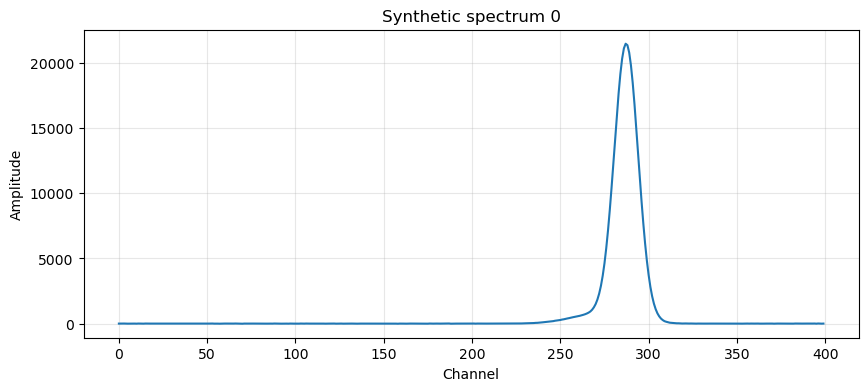

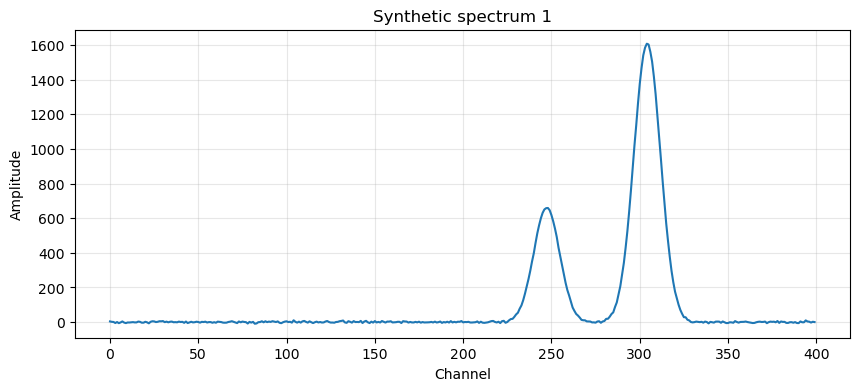

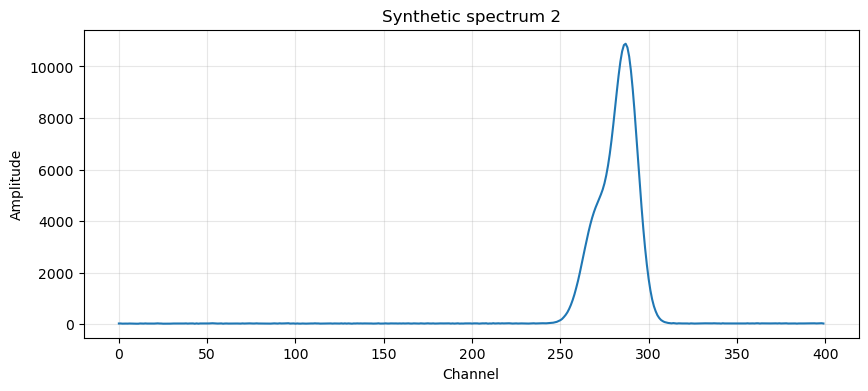

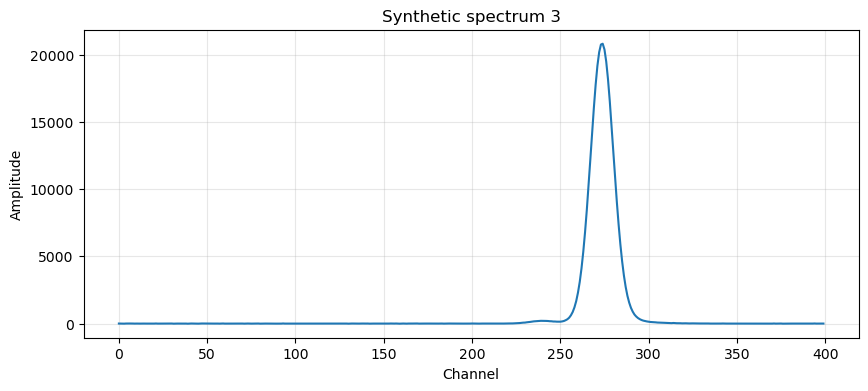

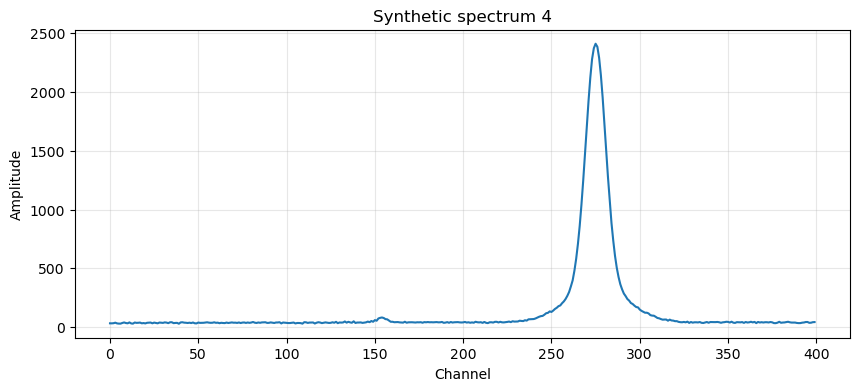

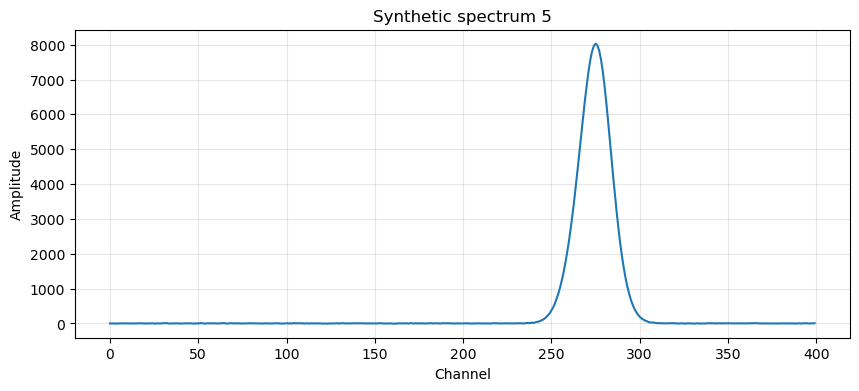

In [13]:
import matplotlib.pyplot as plt

for i in range(6):
    plt.figure(figsize=(10, 4))
    plt.plot(data_train["x_values"][i], data_train["data_list"][i])
    plt.xlabel("Channel")
    plt.ylabel("Amplitude")
    plt.title(f"Synthetic spectrum {i}")
    plt.grid(True, alpha=0.3)
    plt.show()